In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/content/Updated_sales.csv")

In [4]:
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


In [5]:
df.tail()


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
30389,248146,Bose SoundSport Headphones,1,99.99,08/29/19 22:19,"868 Hickory St, San Francisco, CA 94016"
30390,248147,AAA Batteries (4-pack),3,2.99,08/31/19 16:26,"206 Lakeview St, Boston, MA 02215"
30391,248148,AA Batteries (4-pack),1,3.84,08/02/19 07:25,"568 13th St, Seattle, WA 98101"
30392,248149,USB-C Charging Cable,1,11.95,08/08/19 12:10,"495 Walnut St, San Francisco, CA 94016"
30393,248150,AA Batteries (4-pack),1,3.84,08/16/19 08:13,"738 Park St, Los Angeles, CA 90001"


In [6]:
df.shape

(30394, 6)

In [7]:
df.columns

Index(['Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Order Date',
       'Purchase Address'],
      dtype='object')

In [8]:
df.dtypes

,0
Order ID,object
Product,object
Quantity Ordered,object
Price Each,object
Order Date,object
Purchase Address,object


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30394 entries, 0 to 30393
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Order ID          30307 non-null  object
 1   Product           30307 non-null  object
 2   Quantity Ordered  30307 non-null  object
 3   Price Each        30307 non-null  object
 4   Order Date        30307 non-null  object
 5   Purchase Address  30307 non-null  object
dtypes: object(6)
memory usage: 1.4+ MB


In [10]:
df.describe()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
count,30307,30307,30307,30307,30307,30307
unique,29019,20,9,24,23316,27854
top,Order ID,Lightning Charging Cable,1,14.95,Order Date,Purchase Address
freq,61,3556,27405,3556,61,61


In [11]:
df.isnull().sum()

,0
Order ID,87
Product,87
Quantity Ordered,87
Price Each,87
Order Date,87
Purchase Address,87


In [12]:
clean_df = df.copy()

In [13]:
clean_df.isnull().sum()

,0
Order ID,87
Product,87
Quantity Ordered,87
Price Each,87
Order Date,87
Purchase Address,87


In [14]:
clean_df= clean_df.dropna()

In [15]:
clean_df.shape

(30307, 6)

In [16]:
clean_df.duplicated().sum()

np.int64(100)

In [17]:
clean_df=clean_df.drop_duplicates()

In [18]:
clean_df.shape

(30207, 6)

In [19]:
clean_df.duplicated().sum()

np.int64(0)

In [20]:
clean_df.dtypes

,0
Order ID,object
Product,object
Quantity Ordered,object
Price Each,object
Order Date,object
Purchase Address,object


In [21]:
clean_df=clean_df[clean_df["Order Date"] !="Order Date"]

In [22]:
clean_df["Quantity Ordered"]=clean_df["Quantity Ordered"].astype(int)

In [23]:
clean_df.dtypes

,0
Order ID,object
Product,object
Quantity Ordered,int64
Price Each,object
Order Date,object
Purchase Address,object


In [24]:
clean_df["Price Each"]= clean_df["Price Each"].astype(float)

In [25]:
clean_df.dtypes

,0
Order ID,object
Product,object
Quantity Ordered,int64
Price Each,float64
Order Date,object
Purchase Address,object


In [26]:
clean_df["Order Date"]=pd.to_datetime(clean_df["Order Date"])

/tmp/ipykernel_3021/1679122863.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  clean_df["Order Date"]=pd.to_datetime(clean_df["Order Date"])


In [27]:
clean_df.dtypes

,0
Order ID,object
Product,object
Quantity Ordered,int64
Price Each,float64
Order Date,datetime64[ns]
Purchase Address,object


In [73]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30206 entries, 0 to 30393
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order ID          30206 non-null  object        
 1   Product           30206 non-null  object        
 2   Quantity Ordered  30206 non-null  int64         
 3   Price Each        30206 non-null  float64       
 4   Order Date        30206 non-null  datetime64[ns]
 5   Purchase Address  30206 non-null  object        
 6   Sales             30206 non-null  float64       
 7   Month             30206 non-null  int32         
 8   Day               30206 non-null  int32         
 9   Hour              30206 non-null  int32         
 10  City              30206 non-null  object        
dtypes: datetime64[ns](1), float64(2), int32(3), int64(1), object(4)
memory usage: 2.4+ MB


In [29]:
clean_df.to_csv("clean_sales_data.csv", index=False)

In [30]:
from google.colab import files
files.download("clean_sales_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
clean_df["Sales"]= clean_df["Quantity Ordered"] * clean_df["Price Each"]

In [32]:
clean_df.head()


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Sales
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",23.90
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",99.99
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",600.00
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",11.99
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",11.99


In [33]:
clean_df["Month"]= clean_df["Order Date"].dt.month

In [34]:
clean_df[["Order Date","Month"]].head()

,Order Date,Month
0,2019-04-19 08:46:00,4
2,2019-04-07 22:30:00,4
3,2019-04-12 14:38:00,4
4,2019-04-12 14:38:00,4
5,2019-04-30 09:27:00,4


In [35]:
clean_df["Day"]= clean_df["Order Date"].dt.day

In [36]:
clean_df["Hour"]=clean_df["Order Date"].dt.hour

In [37]:
def get_city(address):
    return address.split(",")[1].strip()
clean_df["City"]=clean_df["Purchase Address"].apply(get_city)

In [38]:
clean_df[["Purchase Address","City"]].head()

,Purchase Address,City
0,"917 1st St, Dallas, TX 75001",Dallas
2,"682 Chestnut St, Boston, MA 02215",Boston
3,"669 Spruce St, Los Angeles, CA 90001",Los Angeles
4,"669 Spruce St, Los Angeles, CA 90001",Los Angeles
5,"333 8th St, Los Angeles, CA 90001",Los Angeles


In [39]:
clean_df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Sales,Month,Day,Hour,City
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",23.90,4,19,8,Dallas
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",99.99,4,7,22,Boston
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",600.00,4,12,14,Los Angeles
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",11.99,4,12,14,Los Angeles
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",11.99,4,30,9,Los Angeles


Exploratory Data Analysis (EDA)

In [40]:
# Total Revenue

clean_df["Sales"].sum()

np.float64(5635634.6499999985)

In [41]:
# Total Oreders

clean_df["Order ID"].nunique()

29018

In [42]:
#Average Order Value

top_products = clean_df.groupby("Product")["Quantity Ordered"].sum().sort_values(ascending=False)
top_products.head(10)

,Quantity Ordered
Product,
AAA Batteries (4-pack),4950
AA Batteries (4-pack),4647
Lightning Charging Cable,3803
USB-C Charging Cable,3723
Wired Headphones,3353
Apple Airpods Headphones,2532
Bose SoundSport Headphones,2165
27in FHD Monitor,1228
iPhone,1133


In [43]:
# Top 10 Best Selling Products

top_products = clean_df.groupby("Product")["Quantity Ordered"].sum().sort_values(ascending=False)
top_products.head(10)

,Quantity Ordered
Product,
AAA Batteries (4-pack),4950
AA Batteries (4-pack),4647
Lightning Charging Cable,3803
USB-C Charging Cable,3723
Wired Headphones,3353
Apple Airpods Headphones,2532
Bose SoundSport Headphones,2165
27in FHD Monitor,1228
iPhone,1133


In [44]:
# Top 10 Revenue Generating Products

top_revenue = clean_df.groupby("Product")["Sales"].sum().sort_values(ascending=False)
top_revenue.head(10)

,Sales
Product,
Macbook Pro Laptop,1280100.00
iPhone,793100.00
ThinkPad Laptop,666993.33
Google Phone,564600.00
34in Ultrawide Monitor,391769.69
27in 4K Gaming Monitor,391159.97
Apple Airpods Headphones,379800.00
Flatscreen TV,236700.00
Bose SoundSport Headphones,216478.35


In [45]:
# Sales By Month

monthly_sales = clean_df.groupby("Month")["Sales"].sum()
monthly_sales

,Sales
Month,
4,3384047.56
5,10559.29
8,2238931.06
9,2096.74


In [46]:
# Sales By City


city_sales = clean_df.groupby("City")["Sales"].sum()
city_sales

,Sales
City,
Atlanta,453695.68
Austin,298247.21
Boston,593725.52
Dallas,432379.00
Los Angeles,894947.08
New York City,748830.79
Portland,393252.85
San Francisco,1355726.22
Seattle,464830.30


In [47]:
# Orders By Hour

hourly_orders = clean_df.groupby("Hour")["Order ID"].count()
hourly_orders

,Order ID
Hour,
0,622
1,381
2,217
3,138
4,139
5,240
6,429
7,676
8,1052


In [48]:
# Highest Priced Products

clean_df.groupby("Product")["Price Each"].max().sort_values(ascending=False).head(10)

,Price Each
Product,
Macbook Pro Laptop,1700.00
ThinkPad Laptop,999.99
iPhone,700.00
LG Washing Machine,600.00
LG Dryer,600.00
Google Phone,600.00
Vareebadd Phone,400.00
27in 4K Gaming Monitor,389.99
34in Ultrawide Monitor,379.99


In [49]:
# Moust Frequently Purchased Products

clean_df["Product"].value_counts().head(10)


,count
Product,
Lightning Charging Cable,3547
AA Batteries (4-pack),3418
USB-C Charging Cable,3414
AAA Batteries (4-pack),3325
Wired Headphones,3079
Apple Airpods Headphones,2512
Bose SoundSport Headphones,2148
27in FHD Monitor,1219
iPhone,1131


In [50]:
import os
os.makedirs("Charts",exist_ok=True)

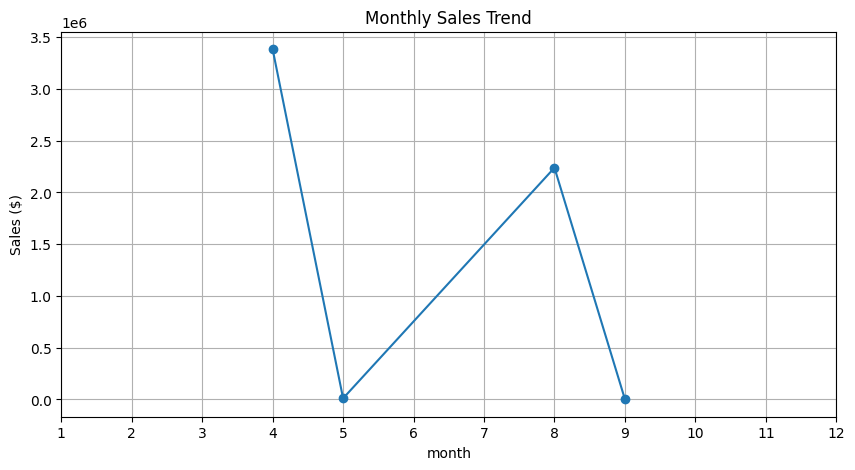

In [51]:
monthly_sales=clean_df.groupby("Month")["Sales"].sum()
plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index,monthly_sales.values,marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("month")
plt.ylabel("Sales ($)")
plt.xticks(range(1,13))
plt.grid(True)
plt.savefig("Charts/monthly_sales_trend.png")
plt.show()

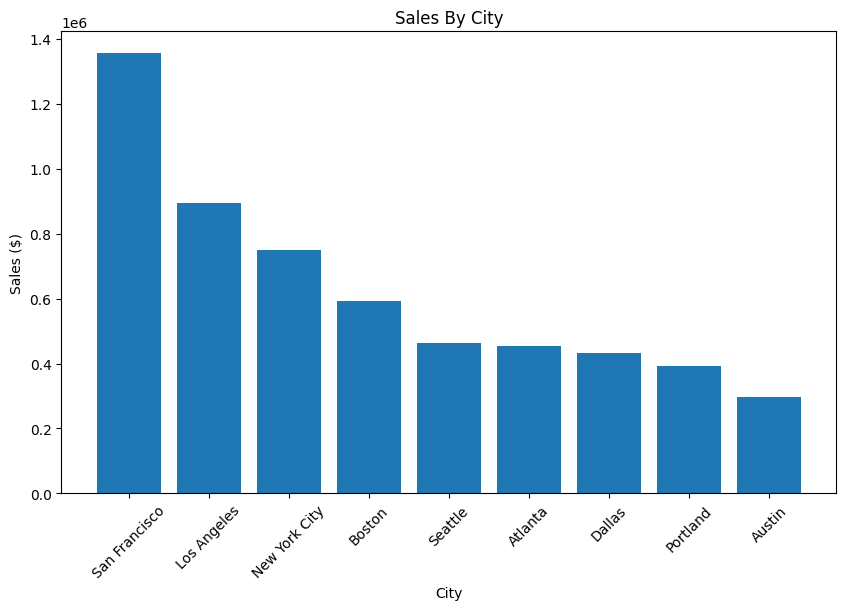

In [52]:
# Sales By City

city_sales=clean_df.groupby("City")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
plt.bar(city_sales.index,city_sales.values)
plt.title("Sales By City")
plt.xlabel("City")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)
plt.savefig("Charts/city_sales.png")
plt.show()

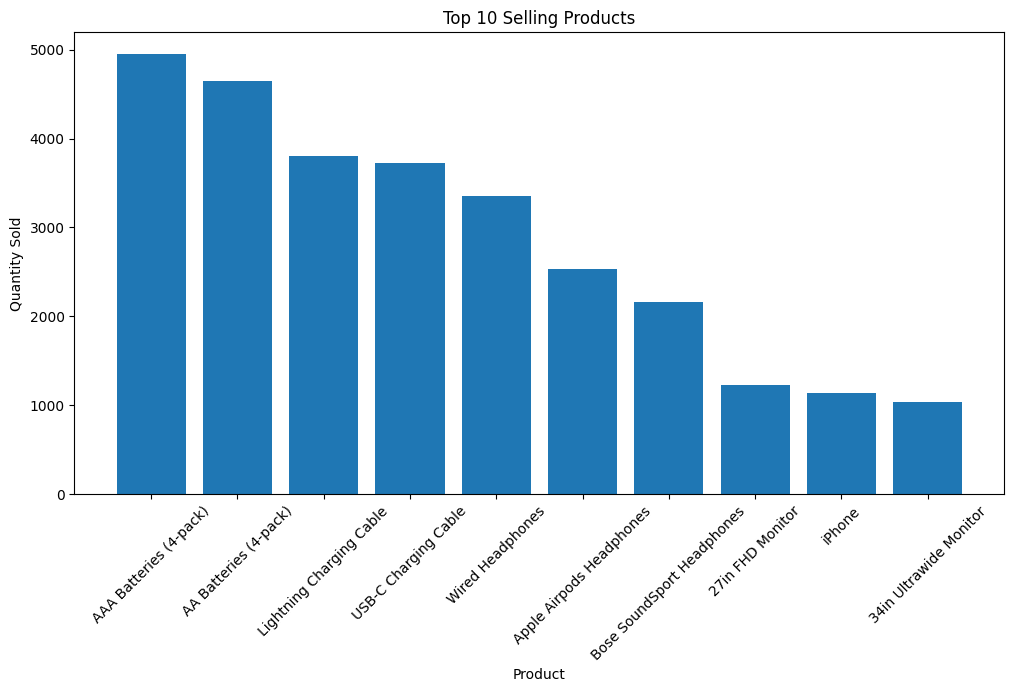

In [53]:
# Top 10 Selling Products

top_products =(clean_df.groupby("Product")["Quantity Ordered"].sum().sort_values(ascending=False).head(10))

plt.figure(figsize=(12,6))
plt.bar(top_products.index,top_products.values)

plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.savefig("Charts/top_products.png")
plt.show()

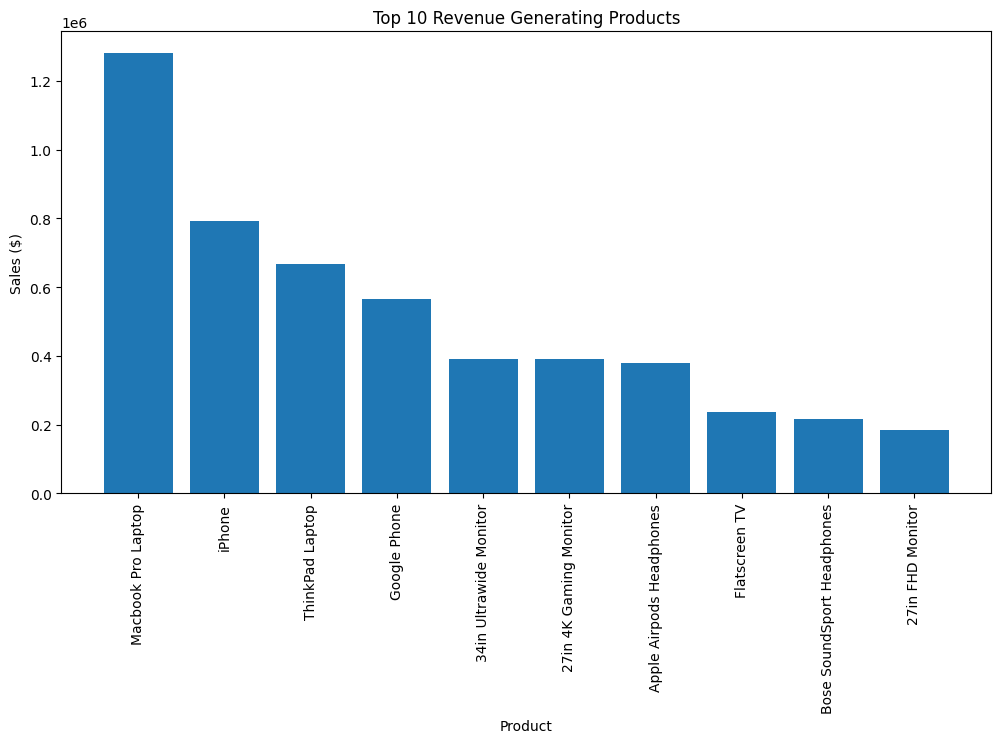

In [57]:
# Top 10 Revenue Generating Products

top_revenue =(clean_df.groupby("Product")["Sales"].sum().sort_values(ascending=False).head(10))
plt.figure(figsize=(12,6))
plt.bar(top_revenue.index,top_revenue.values)
plt.title("Top 10 Revenue Generating Products")

plt.xlabel("Product")
plt.ylabel("Sales ($)")
plt.xticks(rotation=90)
plt.savefig("Charts/top_revenue_products.png")
plt.show()

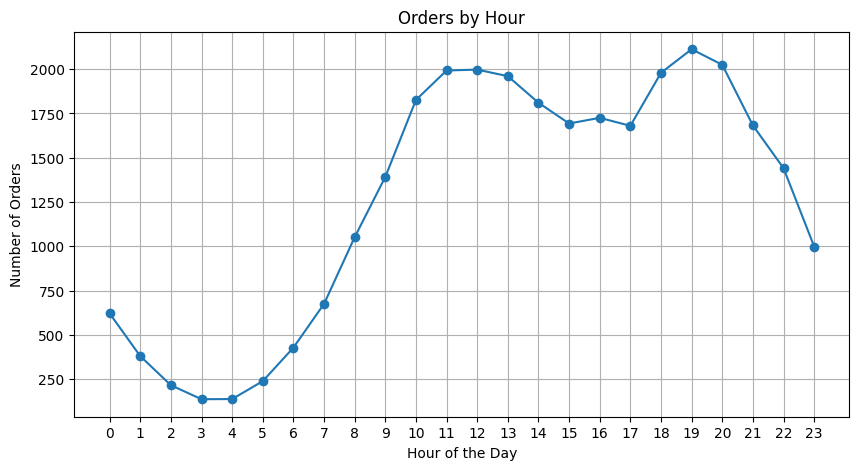

In [58]:
# Order by Hour


hourly_orders = clean_df.groupby("Hour")["Order ID"].count()
plt.figure(figsize=(10,5))
plt.plot(hourly_orders.index, hourly_orders.values, marker='o')
plt.title("Orders by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Orders")
plt.xticks(range(0,24))
plt.grid(True)
plt.savefig("Charts/orders_by_hour.png")
plt.show()

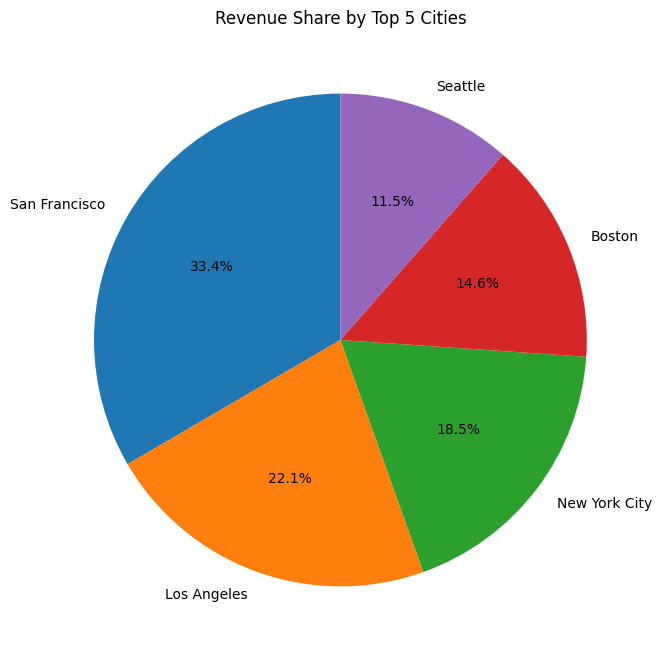

In [59]:
# Revenue Share by Top 5 Cities

top5_city = city_sales.head(5)
plt.figure(figsize=(8,8))
plt.pie(top5_city.values,labels=top5_city.index,autopct='%1.1f%%',startangle=90)
plt.title("Revenue Share by Top 5 Cities")
plt.savefig("Charts/top5_city_pie.png")
plt.show()

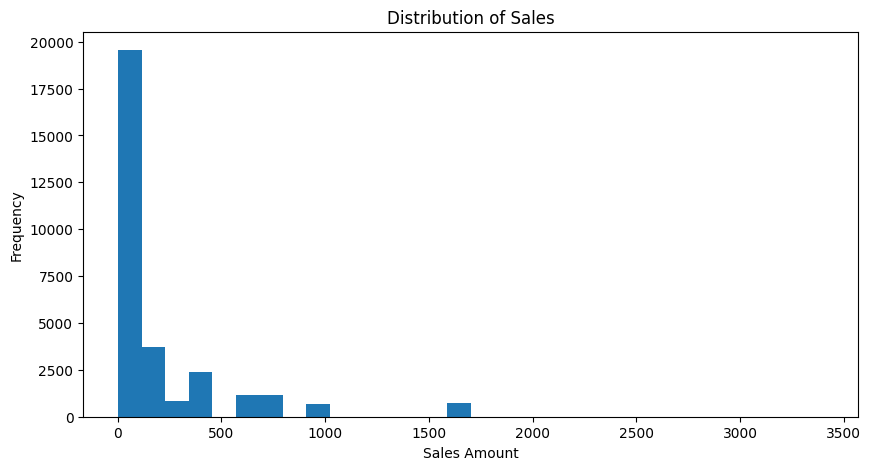

In [61]:
# Distribution of Sales

plt.figure(figsize=(10,5))
plt.hist(clean_df["Sales"], bins=30)
plt.title("Distribution of Sales")
plt.xlabel("Sales Amount")
plt.ylabel("Frequency")
plt.savefig("Charts/sales_distribution.png")
plt.show()

In [64]:
# Key Performance Indicators

total_revenue = clean_df["Sales"].sum()
total_orders = clean_df["Order ID"].nunique()
total_products_sold = clean_df["Quantity Ordered"].sum()
average_order_value = clean_df["Sales"].mean()
total_cities = clean_df["City"].nunique()
total_products = clean_df["Product"].nunique()

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Products Sold: {total_products_sold:,}")
print(f"Average Order Value: ${average_order_value:,.2f}")
print(f"Cities Served: {total_cities}")
print(f"Unique Products: {total_products}")

Total Revenue: $5,635,634.65
Total Orders: 29,018
Products Sold: 33,969
Average Order Value: $186.57
Cities Served: 9
Unique Products: 19


In [66]:
# Top Revenue Product

top_revenue_product = clean_df.groupby("Product")["Sales"].sum().idxmax()
top_revenue_value = clean_df.groupby("Product")["Sales"].sum().max()

print(top_revenue_product)
print(top_revenue_value)

Macbook Pro Laptop
1280100.0


In [67]:
# Best-Selling Product

best_selling = clean_df.groupby("Product")["Quantity Ordered"].sum().idxmax()
best_quantity = clean_df.groupby("Product")["Quantity Ordered"].sum().max()

print(best_selling)
print(best_quantity)

AAA Batteries (4-pack)
4950


In [69]:
# Highest Revenue City

best_city = clean_df.groupby("City")["Sales"].sum().idxmax()
city_sales = clean_df.groupby("City")["Sales"].sum().max()

print(best_city)
print(city_sales)

San Francisco
1355726.22


In [71]:
# Best Month

best_month = clean_df.groupby("Month")["Sales"].sum().idxmax()
month_sales = clean_df.groupby("Month")["Sales"].sum().max()

print(best_month)
print(month_sales)

4
3384047.56


In [72]:
# Peak Shopping Hour

peak_hour = clean_df.groupby("Hour")["Order ID"].count().idxmax()
print(peak_hour)

19


# Executive Summary

This project analyzes over 30,000 e-commerce sales records using Python and Pandas.

The analysis focuses on sales performance, customer purchasing patterns, product demand, and city-wise revenue distribution.

Key performance indicators were calculated, trends were visualized using Matplotlib, and business insights were generated to support data-driven decision-making.

The analysis identified the highest-performing products, best sales months, top revenue-generating cities, and peak shopping hours.



---


**Business Insights**


1.   The total revenue generated from all orders was $5,635,634.65
2.   The best-selling product was AAA Battery (pack 4) with 4950 units sold.



1.   The highest revenue-generating product was Macbook Pro Laptop generating $1280100.0
2.   The city contributing the highest revenue was San Francisco.

1.   Month 4 recorded the highest sales.
2.   Customer purchasing activity peaked around 19 o'clock.

1.   The average order value was $186.57.
2.   The company served customers across 9 cities.




---


**Business Recommendations**





1.  Increase inventory for top-selling products to prevent stock shortages.
2.  Launch promotional campaigns before the highest-performing sales month.

1.  Increase advertising investment in the highest revenue-generating city.

1.  Schedule marketing campaigns around peak shopping hours.
2.  Bundle slow-moving products with best-selling products to increase sales.















# Conclusion

The E-commerce Sales Analytics project demonstrates how Python can be used to clean, analyze, and visualize business data.

The project identified important sales trends, customer behavior, and business opportunities.

The insights generated can help management optimize inventory planning, marketing strategies, and revenue growth.